# Customer Behavior Analysis

Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

Loading Dataset

In [2]:
df = pd.read_csv("customer_behavior.csv")

df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


Dataset information for basic understanding

In [3]:
print(df.shape)

print(df.columns)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(250000, 13)
Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 1

In [4]:
print(df.columns)

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')


Data cleaning from Dataset

In [5]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Fill missing values (forward fill)
df.ffill(inplace=True)

# Rename columns (replace spaces with underscore)
df.columns = df.columns.str.replace(' ', '_')

# Convert Purchase_Date into datetime (safe conversion)
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'], errors='coerce')

# Show first 5 rows
print(df.head())

# Check missing values
print(df.isnull().sum())

   Customer_ID       Purchase_Date Product_Category  Product_Price  Quantity  \
0        46251 2020-09-08 09:38:32      Electronics             12         3   
1        46251 2022-03-05 12:56:35             Home            468         4   
2        46251 2022-05-23 18:18:01             Home            288         2   
3        46251 2020-11-12 13:13:29         Clothing            196         1   
4        13593 2020-11-27 17:55:11             Home            449         1   

   Total_Purchase_Amount Payment_Method  Customer_Age  Returns  \
0                    740    Credit Card            37      0.0   
1                   2739         PayPal            37      0.0   
2                   3196         PayPal            37      0.0   
3                   3509         PayPal            37      0.0   
4                   3452    Credit Card            49      0.0   

         Customer_Name  Age  Gender  Churn  
0  Christine Hernandez   37    Male      0  
1  Christine Hernandez   37    M

Feature Engineering

In [6]:
# Extract month
df['Month'] = df['Purchase_Date'].dt.month

# Extract day name
df['Day_Name'] = df['Purchase_Date'].dt.day_name()

# Create total spending column
df['Total_Spending'] = (
    df['Product_Price'] * df['Quantity']
)

df.head()

,Customer_ID,Purchase_Date,Product_Category,Product_Price,Quantity,Total_Purchase_Amount,Payment_Method,Customer_Age,Returns,Customer_Name,Age,Gender,Churn,Month,Day_Name,Total_Spending
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0,9,Tuesday,36
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0,3,Saturday,1872
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0,5,Monday,576
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0,11,Thursday,196
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1,11,Friday,449


Exploratory Data Analysis (EDA)

1. Distribution of Customer Spending

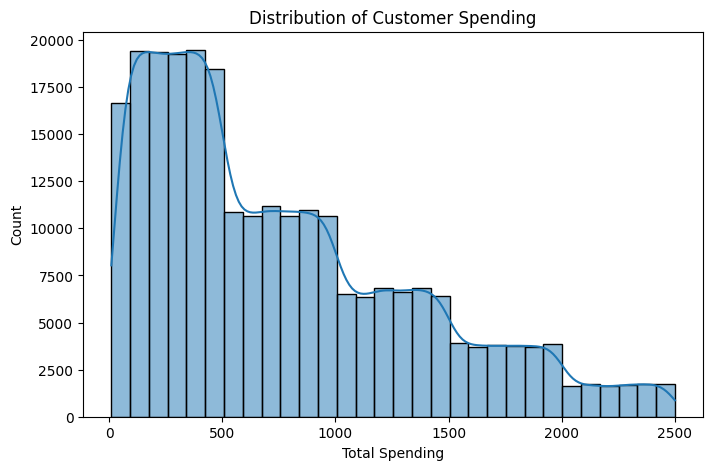

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Total_Spending'],
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Spending")

plt.xlabel("Total Spending")

plt.ylabel("Count")

plt.show()

2. Monthly Sales Trend Analysis

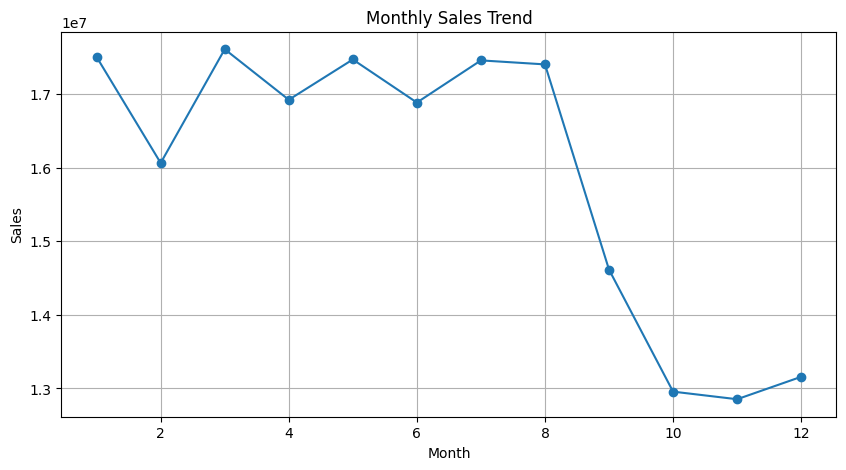

In [8]:
monthly_sales = df.groupby('Month')[
    'Total_Spending'
].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(
    marker='o'
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid()

plt.show()

3. Top Products

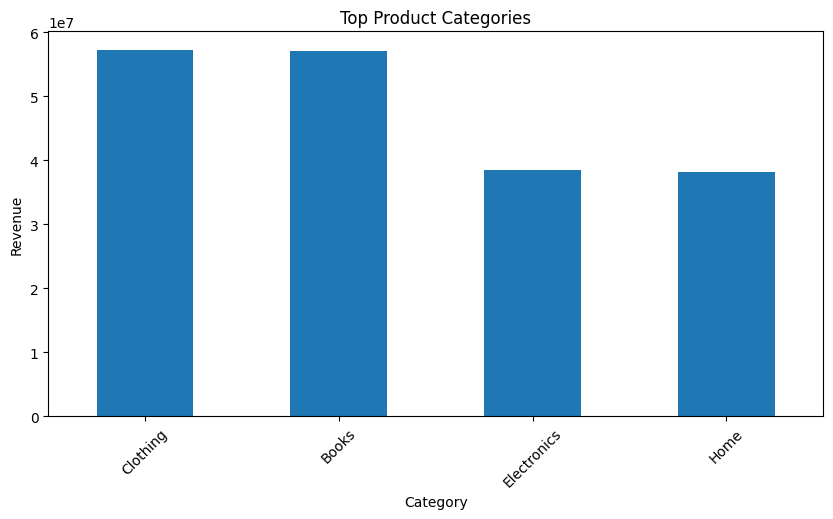

In [9]:
top_products = df.groupby(
    'Product_Category'
)['Total_Spending'].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(10,5))

top_products.plot(kind='bar')

plt.title("Top Product Categories")

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

4. Payment Method Analysis

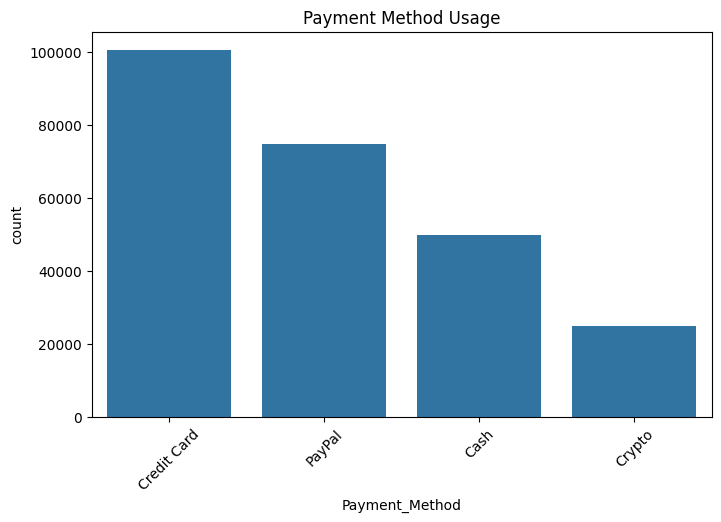

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Payment_Method'
)

plt.title("Payment Method Usage")

plt.xticks(rotation=45)

plt.show()

Gender Analysis

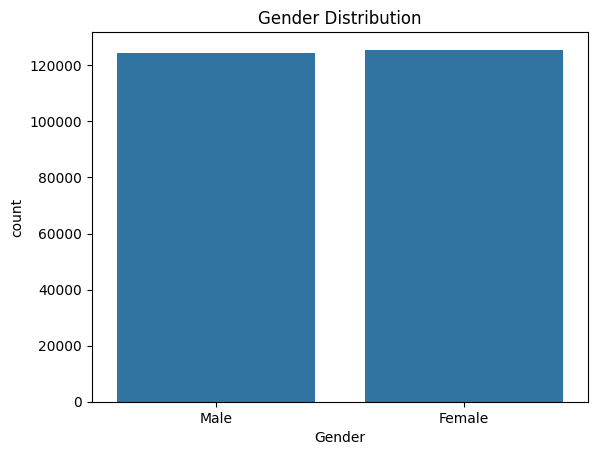

In [11]:
sns.countplot(
    data=df,
    x='Gender'
)

plt.title("Gender Distribution")

plt.show()

Churn Distribution

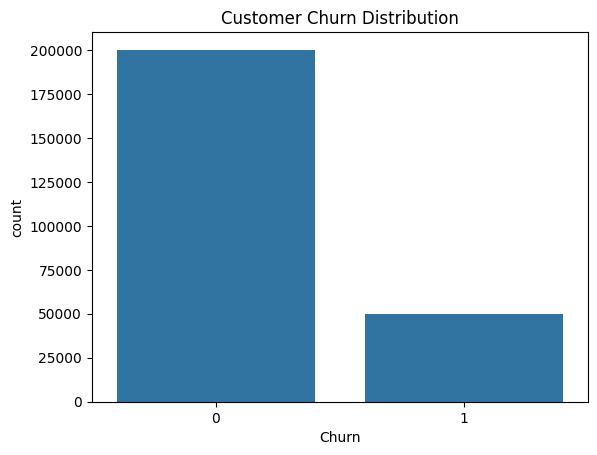

In [12]:
sns.countplot(
    data=df,
    x='Churn'
)

plt.title("Customer Churn Distribution")

plt.show()

Churn by Gender

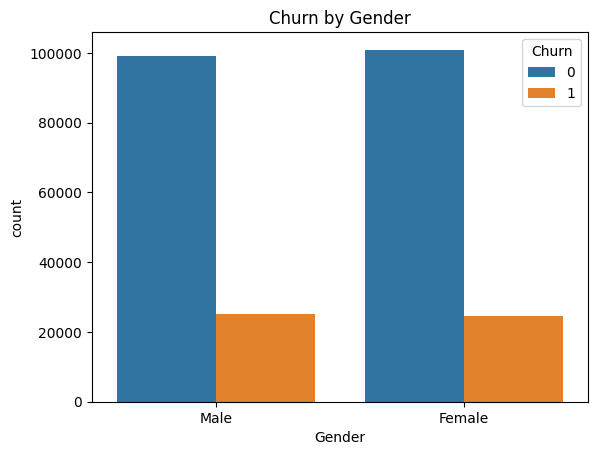

In [13]:
sns.countplot(
    data=df,
    x='Gender',
    hue='Churn'
)

plt.title("Churn by Gender")

plt.show()

RFM Analysis (Customer Segmentation)

RFM means:

Recency → Last purchase
Frequency → Number of purchases
Monetary → Total spending

In [14]:
snapshot_date = (
    df['Purchase_Date'].max()
    + pd.Timedelta(days=1)
)

rfm = df.groupby('Customer_ID').agg({

    'Purchase_Date': lambda x:
    (snapshot_date - x.max()).days,

    'Customer_ID': 'count',

    'Total_Spending': 'sum'

})

rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

rfm.head()

,Recency,Frequency,Monetary
Customer_ID,,,
1,58,1,845
2,299,3,1070
3,89,8,5041
4,127,4,1433
5,171,8,7881


Scaling the data

In [15]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

Elbow method

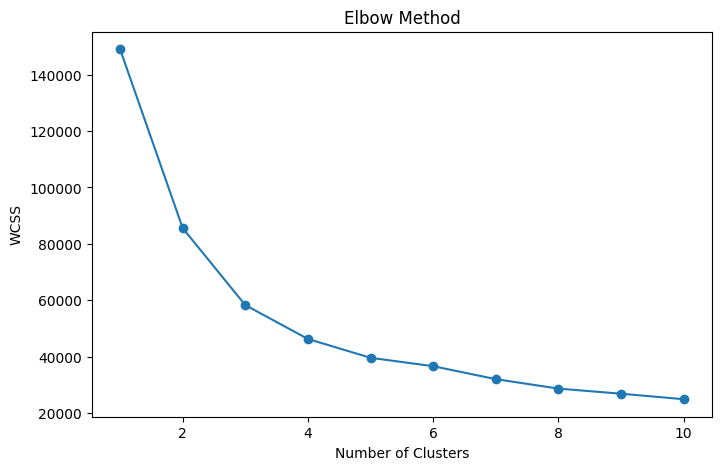

In [16]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

K-Means Clustering

In [17]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['Cluster'] = kmeans.fit_predict(
    rfm_scaled
)

rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer_ID,,,,
1,58,1,845,1
2,299,3,1070,1
3,89,8,5041,2
4,127,4,1433,1
5,171,8,7881,2


Visualize Customer Segments

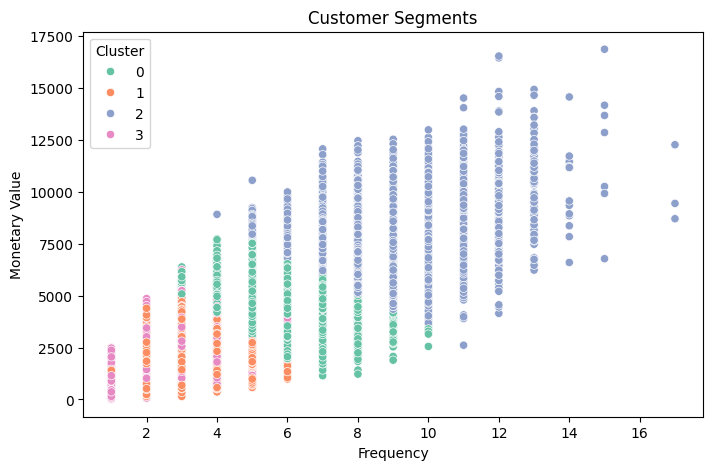

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=rfm['Frequency'],
    y=rfm['Monetary'],
    hue=rfm['Cluster'],
    palette='Set2'
)

plt.title("Customer Segments")

plt.xlabel("Frequency")

plt.ylabel("Monetary Value")

plt.show()

Segment Profiling

In [19]:
segment_profile = rfm.groupby(
    'Cluster'
).mean()

print(segment_profile)

            Recency  Frequency     Monetary
Cluster                                    
0        182.004836   5.824233  4473.554795
1        189.927087   3.449203  2220.781644
2        138.988074   8.417928  7277.206848
3        716.218380   2.961954  2182.704370


Churn Risk Identification

In [20]:
high_risk = rfm[

    (rfm['Recency']
     > rfm['Recency'].median())

    &

    (rfm['Frequency']
     < rfm['Frequency'].median())

]

print(high_risk.head())

             Recency  Frequency  Monetary  Cluster
Customer_ID                                       
2                299          3      1070        1
7                566          3      3155        3
34               972          2      3750        3
36               212          4      4492        0
37               316          4      2306        1


Retention Trend Visualization

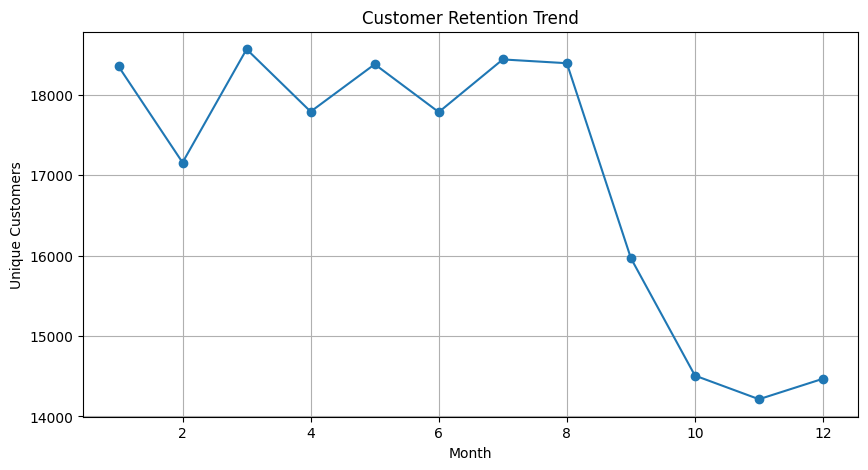

In [21]:
retention = df.groupby(
    'Month'
)['Customer_ID'].nunique()

plt.figure(figsize=(10,5))

retention.plot(
    marker='o'
)

plt.title("Customer Retention Trend")

plt.xlabel("Month")

plt.ylabel("Unique Customers")

plt.grid()

plt.show()

Return Analysis

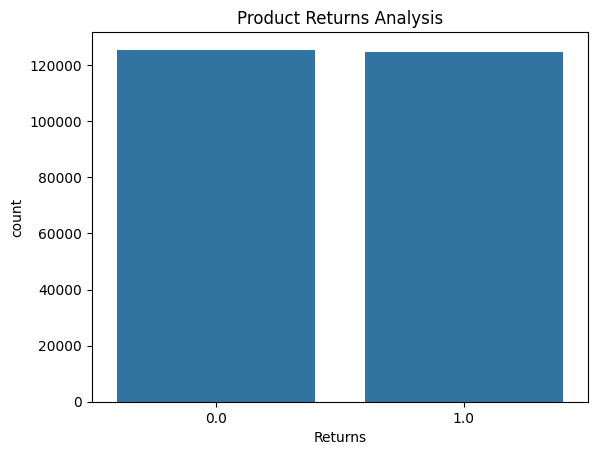

In [22]:
sns.countplot(
    data=df,
    x='Returns'
)

plt.title("Product Returns Analysis")

plt.show()

Correlation Heatmap

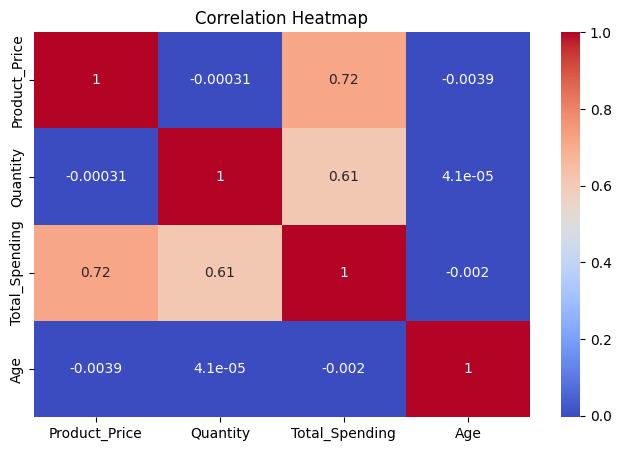

In [23]:
plt.figure(figsize=(8,5))

sns.heatmap(

    df[['Product_Price',
        'Quantity',
        'Total_Spending',
        'Age']].corr(),

    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

5 Recommendations for Alfido Tech

In [24]:
print("Recommendations")

print("--------------------------------")

print("1. Create loyalty programs for frequent buyers.")

print("2. Offer personalized product recommendations.")

print("3. Target churn-risk customers using discounts.")

print("4. Improve customer service to reduce returns.")

print("5. Increase promotions for top-selling categories.")

Recommendations
--------------------------------
1. Create loyalty programs for frequent buyers.
2. Offer personalized product recommendations.
3. Target churn-risk customers using discounts.
4. Improve customer service to reduce returns.
5. Increase promotions for top-selling categories.
